# **05 — Reducción de Dimensionalidad: del FA al PCA**
## Mercado Inmobiliario CABA · Fondo de Inversión

---

### Motivación analítica

El dataset tiene 9 variables candidatas a reducir antes del clustering (nb06): precio/m², superficie, distancias a subte y parque, liquidez comunal, tasa de delitos, volatilidad, índice de amenities y rentabilidad bruta. Sin reducción, el K-Means opera en 9 dimensiones con variables en escalas muy distintas — la geometría se degrada y los clusters pierden cohesión.

Hacemos el ejercicio en **dos pasos secuenciales**, dejando ver la decisión metodológica:

1. **Diagnóstico con Análisis Factorial (FA)** — probamos si las variables admiten constructos latentes interpretables ("valor de ubicación", "calidad del activo", etc.). Si el FA pasara los tests de adecuación, sería preferible: los factores tienen interpretación sustantiva y separan varianza compartida de la idiosincrática. **Spoiler:** KMO global = 0.42 → inadecuado. Las variables no comparten suficiente varianza para sostener un modelo factorial.
2. **Reducción con Análisis de Componentes Principales (PCA)** — pivote justificado. PCA no asume constructos latentes: es descomposición de varianza pura, sin tests de adecuación. Lo usamos como reductor "agnóstico" para el clustering.

**Por qué el pivote no es ad-hoc:** FA y PCA son hermanos algebraicos — comparten autovectores de la matriz de correlación. La diferencia es interpretativa, no mecánica. El FA promete constructos latentes y los tests de adecuación verifican esa promesa; al fallar el KMO, el FA no puede prometerlos. El PCA no promete eso: solo encuentra ejes de máxima varianza. Cumple un objetivo más modesto pero válido sin condiciones previas.

**Conexión con el notebook 04 - Validación de hipótesis:**

Los resultados del 04 informan qué esperar de la estructura del PCA:
- H1 mostró que `Distancia_subte_km` tiene efecto despreciable sobre precio/m² y rentabilidad
  (|ρ| < 0.10). Anticipamos que no dominará un eje financiero, pero puede covariar con otras
  variables de localización geográfica.
- H5.b encontró ρ = −0.33 entre tasa de delitos y precio/m² — la correlación más fuerte
  entre variables económicamente independientes del dataset (la única más alta, ρ = −0.81
  entre precio/m² y rentabilidad, es definitoria por construcción del KPI yield = renta/precio).
  Anticipamos que tasa de delitos aportará estructura a algún eje del PCA.
- H2 mostró que la relación tipología-rentabilidad no es monótona y que superficie no
  predice linealmente el yield. Anticipamos que superficie y rentabilidad operen como
  dimensiones parcialmente independientes en el espacio reducido.
- H4 validó el premium de precio en a-estrenar (+27%) sin recuperación proporcional en renta,
  lo que refuerza la tensión precio/rentabilidad como una dimensión con estructura real en
  los datos.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

!pip install factor_analyzer
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print("Setup completado ✓")

/bin/bash: line 1: pip: command not found


Setup completado ✓


## 1. Carga del dataset

Cargamos `dataset_ventas_features.csv` generado en el notebook 02. Aplicamos los **mismos tres filtros de calidad** utilizados en los notebooks 03 y 04 para garantizar coherencia del pipeline.

In [2]:
URL_VENTAS = ('https://raw.githubusercontent.com/kiaranatale/'
              'Trabajo-Practico-Real-State-Analytics/refs/heads/main/'
              'Datos2/processed/dataset_ventas_features.csv')

try:
    df_raw = pd.read_csv(URL_VENTAS)
    print("Cargado desde GitHub ✓")
except Exception:
    df_raw = pd.read_csv('dataset_ventas_features.csv')
    print("Cargado desde archivo local ✓")
print(f"Dataset crudo: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")

Cargado desde GitHub ✓
Dataset crudo: 3,868 filas × 91 columnas


### Filtros de calidad (pipeline estándar del proyecto)

Los tres filtros aplicados de forma consistente en todos los notebooks analíticos:

In [3]:
# ── Constantes del pipeline (modificar aquí si se actualizan criterios) ──────
GEO_OK_FILTER        = True       # Solo propiedades geocodificadas
CONFIANZA_EXCLUIR    = 'baja'     # Excluir renta con baja confianza en análisis de rentabilidad
SUPERPREMIUM_QUANTILE = 0.99      # Umbral de corte para segmento super-premium

# ── Conversión de tipos numéricos ────────────────────────────────────────────
num_cols = ['Precio_USD','Precio_m2_USD','Sup_Cubierta_m2','Renta_estimada_mensual_USD',
            'Renta_m2_USD','Rentabilidad_bruta_anual','Rentabilidad_neta_anual',
            'Payback_anios','Yield_gap_vs_bonos','Distancia_subte_km','Distancia_parque_km',
            'Indice_amenities','Tasa_delitos_comuna','Liquidez_oferta_comuna',
            'Precio_m2_mediano_comuna','Volatilidad_Precio_m2_comuna','Ambientes']
df = df_raw.copy()
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# ── Filtro 1: geo_ok ─────────────────────────────────────────────────────────
n_antes = len(df)
df = df[df['geo_ok'] == GEO_OK_FILTER].reset_index(drop=True)
print(f"Filtro geo_ok=True:          {n_antes:,} → {len(df):,}  (descartados: {n_antes-len(df):,})")

# ── Filtro 2: super-premium ──────────────────────────────────────────────────
p99 = df['Precio_m2_USD'].quantile(SUPERPREMIUM_QUANTILE)
n_antes = len(df)
df = df[df['Precio_m2_USD'] <= p99].reset_index(drop=True)
print(f"Filtro super-premium (>{p99:,.0f} USD/m²): {n_antes:,} → {len(df):,}  (descartados: {n_antes-len(df):,})")

# ── Filtro 3: confianza_renta ────────────────────────────────────────────────
n_antes = len(df)
df = df[df['confianza_renta'] != CONFIANZA_EXCLUIR].reset_index(drop=True)
print(f"Filtro confianza_renta≠baja:  {n_antes:,} → {len(df):,}  (descartados: {n_antes-len(df):,})")
print(f"\nDataset final: {len(df):,} propiedades")

Filtro geo_ok=True:          3,868 → 3,493  (descartados: 375)
Filtro super-premium (>5,771 USD/m²): 3,493 → 3,456  (descartados: 37)
Filtro confianza_renta≠baja:  3,456 → 3,140  (descartados: 316)

Dataset final: 3,140 propiedades


## 2. Taxonomía de variables

Antes de seleccionar qué variables entran al análisis, clasificamos **todas las variables del dataset** según su origen. Este paso responde directamente a la recomendación metodológica de separar variables observadas, imputadas y derivadas para evitar que variables con distinta confiabilidad de dato contaminen la estructura.

| Categoría | Criterio | Confiabilidad para modelado |
|---|---|---|
| **Observadas** | Extraídas directamente del aviso sin transformación | Alta |
| **Imputadas** | Valor reconstruido donde el original era nulo o inconsistente | Media — documentar en cada caso |
| **Derivadas** | Calculadas como función determinista de otras variables | Alta si las inputs son confiables; excluir si son derivadas de la variable objetivo |
| **Excluidas** | Afectadas por bugs de datos o colineales con el target | No usar en modelos |

In [4]:
taxonomia = {
    'OBSERVADAS': [
        'Precio_m2_USD',        # Precio de publicación / sup_cubierta
        'Sup_Cubierta_m2',      # Informado directamente en el aviso
        'Ambientes',            # Informado directamente
        'Indice_amenities',     # Suma de binarios observados (pileta, gym, SUM, etc.)
        'Distancia_subte_km',   # Calculada desde coordenadas observadas
        'Distancia_parque_km',  # Calculada desde coordenadas observadas
        'Tasa_delitos_comuna',  # Fuente externa BA Data, observable por comuna
        'Liquidez_oferta_comuna', #   Conteo de publicaciones activas / población por comuna.
                                #  comunas con más oferta relativa tienen mayor rotación de stock.
    ],
    'IMPUTADAS': [
        'Renta_estimada_mensual_USD',  # Tabla puente: mediana de comparables por (Comuna, Tipología, banda)
                                        # Confianza documentada en columna confianza_renta
        'Volatilidad_Precio_m2_comuna', # Agregado comunal — estable pero depende del n por comuna
    ],
    'DERIVADAS_VALIDAS': [
        'Rentabilidad_bruta_anual',    # (Renta_estimada × 12) / Precio_ajustado.
                              # H2 mostró patrón en U
                              # por tipología (2A peor rendimiento), H4 confirmó que
                              # a-estrenar rinde 137 bps menos, H5.a que zona alto
                              # rinde 73 bps más que zona bajo.
    ],
    'EXCLUIDAS_MODELOS': [
        'Antiguedad',      # Bug de imputación: >60% concentrado en ~40 años artificialmente.
                           # Solo A_estrenar (binario reconstruido vía URL) es confiable.
        'Payback_anios',          # = 1 / Rentabilidad_bruta_anual → tautología con target.
        'Yield_gap_vs_bonos',     # = Rentabilidad_bruta - 0.10 → derivada del target.
        'Precio_USD',             # = Precio_m2_USD × Sup_Cubierta_m2 → determinismo algebraico.
        'Precio_m2_mediano_comuna', # Agregado comunal colineal con Precio_m2_USD.
    ]
}

print("TAXONOMÍA DE VARIABLES DEL DATASET")
print("="*65)
for categoria, vs in taxonomia.items():
    print(f"\n[{categoria}]")
    for v in vs:
        print(f"  • {v}")

print("\n→ Para reducción usamos: OBSERVADAS + IMPUTADAS + DERIVADAS_VALIDAS (con confianza_renta≠baja)")
print("→ EXCLUIDAS_MODELOS no se usan en ningún modelo de esta entrega")

TAXONOMÍA DE VARIABLES DEL DATASET

[OBSERVADAS]
  • Precio_m2_USD
  • Sup_Cubierta_m2
  • Ambientes
  • Indice_amenities
  • Distancia_subte_km
  • Distancia_parque_km
  • Tasa_delitos_comuna
  • Liquidez_oferta_comuna

[IMPUTADAS]
  • Renta_estimada_mensual_USD
  • Volatilidad_Precio_m2_comuna

[DERIVADAS_VALIDAS]
  • Rentabilidad_bruta_anual

[EXCLUIDAS_MODELOS]
  • Antiguedad
  • Payback_anios
  • Yield_gap_vs_bonos
  • Precio_USD
  • Precio_m2_mediano_comuna

→ Para reducción usamos: OBSERVADAS + IMPUTADAS + DERIVADAS_VALIDAS (con confianza_renta≠baja)
→ EXCLUIDAS_MODELOS no se usan en ningún modelo de esta entrega


## 3. Selección de variables para el análisis

Con la taxonomía definida, seleccionamos las 9 variables que entran al diagnóstico FA y al PCA. El criterio es sustantivo: incluimos variables que representan **dimensiones observables** de la decisión de inversión, excluyendo colineales por construcción (precio total, payback, yield gap, precio mediano comunal).

> **Nota sobre `Rentabilidad_bruta_anual`**: la incluimos como input porque el objetivo de este notebook es **mapear la estructura observable del mercado** desde la perspectiva del inversor — rentabilidad es una de esas dimensiones. Esto implica que cualquier componente que la tome como carga dominante la captura por construcción (no es hallazgo emergente). La consecuencia: **no se usan los scores del PCA en el nb07** (modelos explicativos sobre rentabilidad), donde sí habría leakage. Los scores se usan únicamente en el nb06 (clustering) como espacio reducido de segmentación.

In [5]:
ANALISIS_VARS = [
    # Dimensión precio y tamaño
    'Precio_m2_USD',
    'Sup_Cubierta_m2',
    # Dimensión ubicación y accesibilidad
    'Distancia_subte_km',
    'Distancia_parque_km',
    'Liquidez_oferta_comuna',
    # Dimensión riesgo
    'Tasa_delitos_comuna',
    'Volatilidad_Precio_m2_comuna',
    # Dimensión calidad del activo
    'Indice_amenities',
    # Dimensión rentabilidad (entra como input observable, NO como target)
    'Rentabilidad_bruta_anual',
]

VAR_LABELS = {
    'Precio_m2_USD':                'Precio/m²',
    'Sup_Cubierta_m2':              'Superficie (m²)',
    'Distancia_subte_km':           'Dist. subte',
    'Distancia_parque_km':          'Dist. parque',
    'Liquidez_oferta_comuna':       'Liquidez oferta',
    'Tasa_delitos_comuna':          'Tasa delitos',
    'Volatilidad_Precio_m2_comuna': 'Volatilidad precio',
    'Indice_amenities':             'Índice amenities',
    'Rentabilidad_bruta_anual':     'Rentabilidad bruta',
}

df_ana = df[ANALISIS_VARS].dropna().copy()
print(f"Observaciones disponibles: {len(df_ana):,}  ({len(df_ana)/len(df)*100:.1f}% del dataset filtrado)")
print(f"Variables: {len(ANALISIS_VARS)}")
print()
print("Estadística descriptiva:")
print(df_ana.describe().round(3))

Observaciones disponibles: 3,140  (100.0% del dataset filtrado)
Variables: 9

Estadística descriptiva:
       Precio_m2_USD  Sup_Cubierta_m2  Distancia_subte_km  \
count     3,140.0000       3,140.0000          3,140.0000   
mean      2,591.8940          65.9590              0.9990   
std         892.3180          52.1660              0.8310   
min         331.8580           9.2600              0.0170   
25%       1,987.0950          37.0000              0.4030   
50%       2,500.0000          51.0000              0.7440   
75%       3,122.6560          77.9300              1.3480   
max       5,769.2310         992.0000              6.1370   

       Distancia_parque_km  Liquidez_oferta_comuna  Tasa_delitos_comuna  \
count           3,140.0000              3,140.0000           3,140.0000   
mean                1.7400                  0.0020               0.6250   
std                 0.9780                  0.0000               0.3400   
min                 0.0470                  0.0

## 4. Diagnóstico de correlaciones

Verificamos que existe estructura de correlación entre las variables. Para PCA esto importa porque, sin alguna correlación, los componentes principales captan varianza distribuida casi en partes iguales sin compresión efectiva. Para FA importa todavía más (la varianza compartida es la materia prima del modelo).

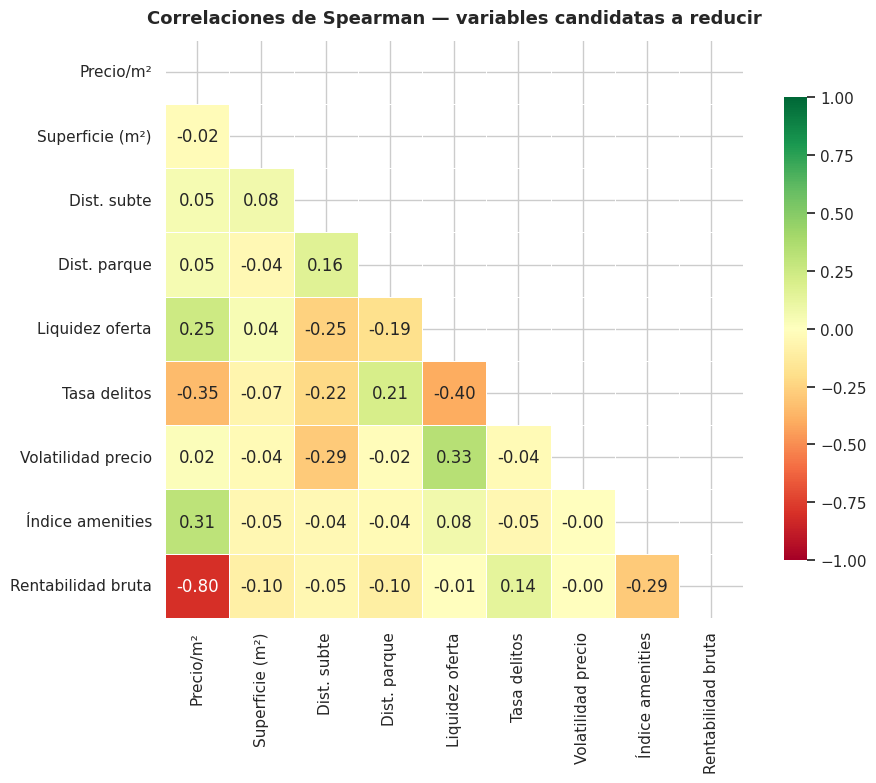

Pares con |ρ| > 0.40:
  Precio/m²                 ↔ Rentabilidad bruta          ρ = -0.805
  Liquidez oferta           ↔ Tasa delitos                ρ = -0.405


In [6]:
corr_matrix = df_ana.rename(columns=VAR_LABELS).corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Correlaciones de Spearman — variables candidatas a reducir', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Pares con correlación sustantiva
print("Pares con |ρ| > 0.40:")
labels = list(VAR_LABELS.values())
found = False
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.40:
            print(f"  {labels[i]:25s} ↔ {labels[j]:25s}   ρ = {r:+.3f}")
            found = True
if not found:
    print("  (ningún par supera el umbral de 0.40 — correlaciones moderadas o débiles)")

**Hallazgo:** las correlaciones son **moderadas a débiles**, a excepción de la **relación inversa** entre *Rentabilidad bruta* y *Precio/m²*. Esto anticipa que cualquier reducción de dimensionalidad va a ser parcial — no hay pares dominantes que indiquen redundancia fuerte. Es una señal temprana de que el espacio no comprime mucho.

## 5. Paso 1 — Diagnóstico FA

Antes de aplicar PCA, probamos si el Análisis Factorial es viable. Si lo fuera, sería preferible: el FA modela varianza compartida y los factores tienen interpretación de constructos latentes (los componentes de PCA solo tienen interpretación de "ejes de máxima varianza").

Dos tests formales determinan si el FA es aplicable:
- **Bartlett**: H₀ = la matriz de correlaciones es identidad (sin estructura). Si rechazamos, existe alguna estructura para modelar.
- **KMO** (Kaiser-Meyer-Olkin): mide cuánto de la varianza es **compartida** vs. **específica** de cada variable. Threshold absoluto: KMO ≥ 0.50; aceptable ≥ 0.70.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ana)

# ── Bartlett ──────────────────────────────────────────────────────────────────
chi2_b, p_b = calculate_bartlett_sphericity(df_ana)
print("TEST DE ESFERICIDAD DE BARTLETT")
print(f"  H₀: matriz de correlaciones = identidad (sin estructura)")
print(f"  χ² = {chi2_b:,.2f}  |  p = {p_b:.2e}")
print(f"  → {'RECHAZAMOS H₀ — hay estructura ✓' if p_b < 0.05 else 'NO rechazamos H₀ — sin estructura'}")

# ── KMO ───────────────────────────────────────────────────────────────────────
kmo_vars, kmo_global = calculate_kmo(df_ana)
adecuacion = ("Excelente ✓" if kmo_global >= 0.90 else "Bueno ✓" if kmo_global >= 0.80
              else "Aceptable ✓" if kmo_global >= 0.70 else "Mediocre — revisar" if kmo_global >= 0.60
              else "Inaceptable ✗")
print(f"\nÍNDICE KMO (Kaiser-Meyer-Olkin):  {kmo_global:.4f}  → {adecuacion}")
print()
print("KMO por variable:")
kmo_df = pd.DataFrame({'Variable': [VAR_LABELS[v] for v in ANALISIS_VARS],
                        'KMO': kmo_vars}).sort_values('KMO', ascending=False)
for _, row in kmo_df.iterrows():
    alerta = "  ⚠ < 0.50" if row['KMO'] < 0.50 else ""
    print(f"  {row['Variable']:25s}  {row['KMO']:.4f}{alerta}")

TEST DE ESFERICIDAD DE BARTLETT
  H₀: matriz de correlaciones = identidad (sin estructura)
  χ² = 4,096.61  |  p = 0.00e+00
  → RECHAZAMOS H₀ — hay estructura ✓

ÍNDICE KMO (Kaiser-Meyer-Olkin):  0.4202  → Inaceptable ✗

KMO por variable:
  Índice amenities           0.5097
  Precio/m²                  0.4801  ⚠ < 0.50
  Rentabilidad bruta         0.4544  ⚠ < 0.50
  Liquidez oferta            0.4237  ⚠ < 0.50
  Tasa delitos               0.4035  ⚠ < 0.50
  Dist. parque               0.3746  ⚠ < 0.50
  Dist. subte                0.3729  ⚠ < 0.50
  Volatilidad precio         0.2978  ⚠ < 0.50
  Superficie (m²)            0.2141  ⚠ < 0.50


**Hallazgo del diagnóstico FA:**

- Bartlett **rechaza H₀** → existe *alguna* estructura de correlación. Pero esto es un mínimo: cualquier dataset con n grande y variables relacionadas pasa Bartlett.
- **KMO global = 0.42** y **8/9 variables con KMO individual < 0.50** → el modelo factorial es **inadecuado**. Las correlaciones parciales (entre cada par controlando por las demás) son tan grandes como las correlaciones simples — lo que significa que cada variable mantiene mayoritariamente su varianza específica, sin compartir varianza con factores latentes comunes.

**Decisión metodológica:** descartamos el FA y pivotamos a **PCA**. PCA es descomposición de varianza pura — no asume constructos latentes y no requiere tests de adecuación. Cumple un objetivo más modesto (reducir dimensionalidad maximizando varianza explicada) pero plenamente válido sin condiciones previas.

Esto es un **hallazgo de negocio**: el mercado inmobiliario de CABA opera en *dimensiones independientes*, no admite una síntesis simple a 2-3 constructos. La decisión de inversión no se reduce a un "score de calidad global" — requiere evaluar varios ejes separadamente.

## 6. Paso 2 — PCA: elección del número de componentes

Estandarizamos las variables (PCA es escala-sensible) y ajustamos un PCA con el máximo de componentes para inspeccionar la distribución de varianza. Tres criterios para decidir cuántos retener:

- **Kaiser**: componentes con autovalor > 1 (sobre datos estandarizados → varianza unitaria por variable).
- **Scree plot**: codo en la curva de autovalores.
- **Varianza acumulada**: umbral convencional ≥ 60%-80%, ajustado a la naturaleza del problema.

Para nuestro caso, además ponderamos un criterio extra: **el número de dimensiones del clustering posterior**. K-Means en 3-5 dimensiones es óptimo (alcanza a tener geometría útil sin sufrir la maldición de la dimensionalidad). Si las métricas estadísticas dejan margen, priorizamos esa banda.

In [8]:
pca_full = PCA()
pca_full.fit(X_scaled)

eigenvalues = pca_full.explained_variance_
var_ratio   = pca_full.explained_variance_ratio_
cum_var     = np.cumsum(var_ratio) * 100

print(f"{'Componente':>12}  {'Autovalor':>10}  {'Var.%':>8}  {'Acum.%':>8}  {'Kaiser(>1)':>11}")
for i, (ev, vr, cv) in enumerate(zip(eigenvalues, var_ratio, cum_var), 1):
    mark = '✓' if ev > 1 else ''
    print(f"  PC{i:>2}        {ev:>8.4f}   {vr*100:>7.2f}%  {cv:>7.2f}%   {mark:>10s}")

n_kaiser = int((eigenvalues > 1).sum())
print(f"\nRegla de Kaiser: {n_kaiser} componentes (autovalor > 1)")
n_60 = int(np.searchsorted(cum_var, 60.0) + 1)
n_80 = int(np.searchsorted(cum_var, 80.0) + 1)
print(f"Componentes para ≥60% var. acumulada: {n_60}")
print(f"Componentes para ≥80% var. acumulada: {n_80}")

  Componente   Autovalor     Var.%    Acum.%   Kaiser(>1)
  PC 1          1.8950     21.05%    21.05%            ✓
  PC 2          1.6007     17.78%    38.83%            ✓
  PC 3          1.2119     13.46%    52.29%            ✓
  PC 4          1.0478     11.64%    63.93%            ✓
  PC 5          0.9302     10.33%    74.26%             
  PC 6          0.8377      9.30%    83.57%             
  PC 7          0.8088      8.98%    92.55%             
  PC 8          0.3608      4.01%    96.56%             
  PC 9          0.3100      3.44%   100.00%             

Regla de Kaiser: 4 componentes (autovalor > 1)
Componentes para ≥60% var. acumulada: 4
Componentes para ≥80% var. acumulada: 6


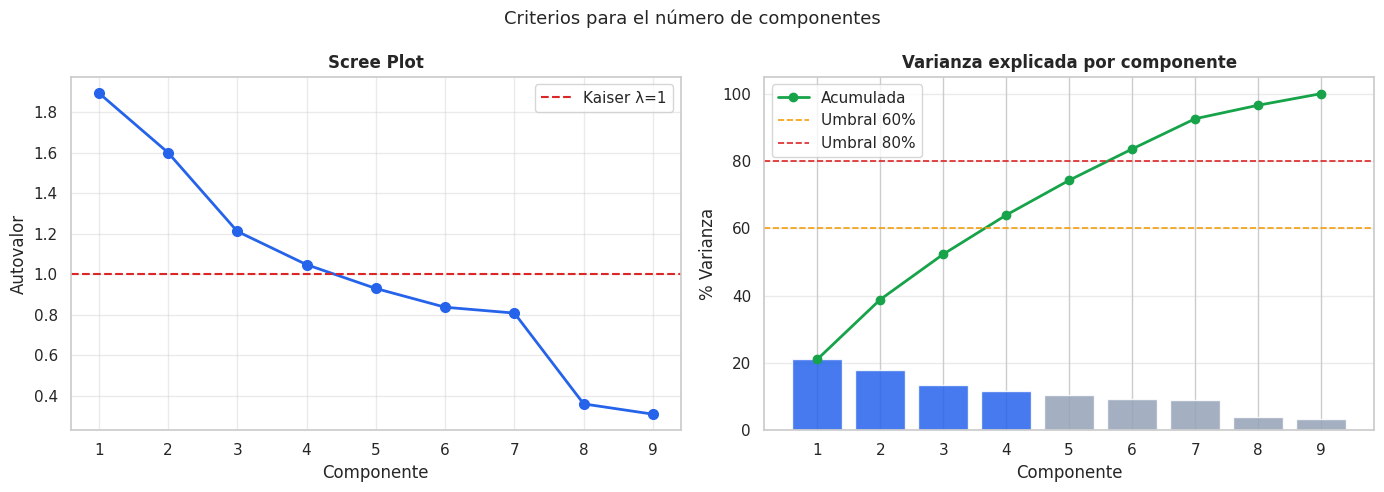

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='#2563eb', lw=2, ms=7)
axes[0].axhline(1, color='#dc2626', ls='--', lw=1.5, label='Kaiser λ=1')
axes[0].set(xlabel='Componente', ylabel='Autovalor', title='Scree Plot')
axes[0].set_xticks(range(1, len(eigenvalues)+1))
axes[0].legend(); axes[0].grid(alpha=0.4)

# Varianza acumulada
colors = ['#2563eb' if i < n_kaiser else '#94a3b8' for i in range(len(cum_var))]
axes[1].bar(range(1, len(cum_var)+1), var_ratio*100, color=colors, alpha=0.85, edgecolor='white')
axes[1].plot(range(1, len(cum_var)+1), cum_var, 'o-', color='#16a34a', lw=2, ms=6, label='Acumulada')
axes[1].axhline(60, color='#f59e0b', ls='--', lw=1.2, label='Umbral 60%')
axes[1].axhline(80, color='#dc2626', ls='--', lw=1.2, label='Umbral 80%')
axes[1].set(xlabel='Componente', ylabel='% Varianza', title='Varianza explicada por componente')
axes[1].set_xticks(range(1, len(cum_var)+1))
axes[1].legend(); axes[1].grid(alpha=0.4, axis='y')

plt.suptitle('Criterios para el número de componentes', fontsize=13)
plt.tight_layout()
plt.show()

**Decisión: N_COMPONENTS = 4.**

Con estos datos podemos comprender que para superar el 80% de varianza acumulada necesitaríamos retener 6 de las 9 variables. La reducción es modesta por la baja correlación intervariable (heredada del KMO bajo). Cuatro componentes resulta como el mejor compromiso de varianza retenida (≥60%, también avalado por los criterios de Kaiser y del codo), mantenimiento de la geometría útil para clustering, e interpretabilidad.

In [10]:
N_COMPONENTS = 4

pca = PCA(n_components=N_COMPONENTS)
pca.fit(X_scaled)
scores = pca.transform(X_scaled)

var_ratio_sel = pca.explained_variance_ratio_
cum_var_sel   = np.cumsum(var_ratio_sel) * 100

print(f"PCA — {N_COMPONENTS} componentes")
print(f"Varianza explicada: " + " | ".join(
    [f"PC{i+1}={var_ratio_sel[i]*100:.1f}%" for i in range(N_COMPONENTS)]))
print(f"Total: {cum_var_sel[-1]:.1f}%")

PCA — 4 componentes
Varianza explicada: PC1=21.0% | PC2=17.8% | PC3=13.5% | PC4=11.6%
Total: 63.9%


## 7. Loadings e interpretación de componentes

Las cargas (loadings) de PCA = correlaciones entre las variables originales y los componentes principales, calculadas como `components_.T × √autovalores`. |loading| ≥ 0.45 indica que la variable "carga" sustantivamente sobre ese componente.

In [11]:
# Loadings = correlation between variables and components on standardized data
loadings = pd.DataFrame(
    (pca.components_.T * np.sqrt(pca.explained_variance_)),
    index=[VAR_LABELS[v] for v in ANALISIS_VARS],
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

# Comunalidades = sum of squared loadings per variable
comunalidades = (loadings ** 2).sum(axis=1).values

print(f"{'Variable':25s}", end='')
for j in range(N_COMPONENTS): print(f"{'PC'+str(j+1):>10}", end='')
print(f"{'Comunalidad':>13}")
print("-"*70)
for i, var in enumerate(loadings.index):
    row = f"{var:25s}"
    for j in range(N_COMPONENTS):
        val = loadings.iloc[i, j]
        marker = "*" if abs(val) >= 0.45 else " "
        row += f"{val:>9.3f}{marker}"
    calidad = "✓" if comunalidades[i] >= 0.50 else "⚠"
    row += f"{comunalidades[i]:>12.3f}  {calidad}"
    print(row)
print("-"*70)
print("* |loading| ≥ 0.45  |  ✓ comunalidad ≥ 0.50  |  ⚠ comunalidad baja")
print(f"\n% Var por componente: " + " | ".join(
    [f"PC{i+1}={var_ratio_sel[i]*100:.1f}%" for i in range(N_COMPONENTS)]))

Variable                        PC1       PC2       PC3       PC4  Comunalidad
----------------------------------------------------------------------
Precio/m²                    0.890*    0.068     0.081    -0.107        0.815  ✓
Superficie (m²)              0.038    -0.037     0.207     0.907*       0.868  ✓
Dist. subte                 -0.009     0.752*   -0.488*    0.114        0.817  ✓
Dist. parque                -0.051     0.646*    0.385    -0.084        0.575  ✓
Liquidez oferta              0.425    -0.597*    0.050     0.066        0.544  ✓
Tasa delitos                -0.486*   -0.255     0.520*   -0.049        0.575  ✓
Volatilidad precio          -0.031     0.333     0.661*   -0.177        0.580  ✓
Índice amenities             0.538*   -0.086     0.055    -0.299        0.390  ⚠
Rentabilidad bruta          -0.624*   -0.268    -0.252    -0.258        0.592  ✓
----------------------------------------------------------------------
* |loading| ≥ 0.45  |  ✓ comunalidad ≥ 0.50  |  ⚠ 

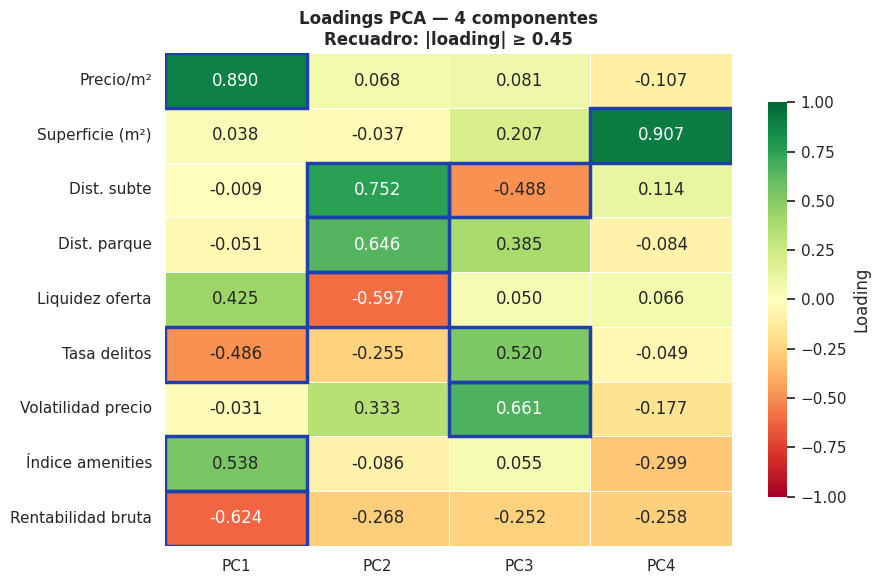


INTERPRETACIÓN DE COMPONENTES (vars que cargan |≥0.45|):

PC1  (21.0% varianza):
  Precio/m²                  loading = +0.890  (↑)
  Rentabilidad bruta         loading = -0.624  (↓)
  Índice amenities           loading = +0.538  (↑)
  Tasa delitos               loading = -0.486  (↓)

PC2  (17.8% varianza):
  Dist. subte                loading = +0.752  (↑)
  Dist. parque               loading = +0.646  (↑)
  Liquidez oferta            loading = -0.597  (↓)

PC3  (13.5% varianza):
  Volatilidad precio         loading = +0.661  (↑)
  Tasa delitos               loading = +0.520  (↑)
  Dist. subte                loading = -0.488  (↓)

PC4  (11.6% varianza):
  Superficie (m²)            loading = +0.907  (↑)


In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Loading'}, ax=ax)
for i in range(len(ANALISIS_VARS)):
    for j in range(N_COMPONENTS):
        if abs(loadings.iloc[i, j]) >= 0.45:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='#1e40af', lw=2.5))
ax.set_title(f'Loadings PCA — {N_COMPONENTS} componentes\nRecuadro: |loading| ≥ 0.45',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nINTERPRETACIÓN DE COMPONENTES (vars que cargan |≥0.45|):")
for j in range(N_COMPONENTS):
    print(f"\nPC{j+1}  ({var_ratio_sel[j]*100:.1f}% varianza):")
    cargas_j = loadings.iloc[:, j]
    relevantes = cargas_j[cargas_j.abs() >= 0.45].sort_values(key=abs, ascending=False)
    if len(relevantes) == 0:
        print(f"  (ninguna variable supera |0.45| — componente difuso)")
    for var, val in relevantes.items():
        print(f"  {var:25s}  loading = {val:+.3f}  ({'↑' if val > 0 else '↓'})")

**Interpretación de componentes — resultados observados:**

**PC1 — "Valor de mercado" (21.0% varianza)**
Dominado por `Precio/m²` (+0.890) e `Índice amenities` (+0.538), con `Rentabilidad bruta` en el polo
opuesto (-0.624). La tensión entre precio alto y rentabilidad baja no es ruido: es la estructura
central del mercado. Las propiedades más caras y mejor equipadas capturan menor yield porque el
precio de compra sube más rápido que el alquiler. Un score alto en PC1 indica activo premium con
retorno comprimido; un score bajo, activo de menor valor con yield potencialmente superior.
Para el fondo, este eje es el más relevante: identificar propiedades con PC1 bajo es identificar
candidatos de mayor rentabilidad.

**PC2 — "Accesibilidad urbana" (17.8% varianza)**
Carga `Dist. subte` (+0.752) y `Dist. parque` (+0.646) juntas, con `Liquidez oferta` en el polo
opuesto (-0.597). Las dos distancias covarían porque zonas periféricas están simultáneamente lejos
de subte y de parques. La liquidez baja en esas zonas confirma que la accesibilidad urbana impulsa
la velocidad de venta. Score alto en PC2 = zona periférica, menor liquidez; score bajo = zona
central, accesible y con mayor rotación de stock.

**PC3 — "Riesgo contextual" (13.5% varianza)**
Cargan `Volatilidad precio` (+0.661) y `Tasa delitos` (+0.520), con `Dist. subte` en el polo
opuesto (-0.488). La asociación entre volatilidad alta, mayor conflictividad y menor distancia al
subte sugiere zonas en proceso de transformación urbana: céntricas pero inestables. Esta tensión
captura zonas de gentrificación potencial — alto riesgo, posible upside. Para el fondo con horizonte
conservador, scores bajos en PC3 son preferibles; un fondo con tolerancia al riesgo podría explorar
el cuadrante PC3 alto con PC1 bajo.

**PC4 — "Tamaño" (11.6% varianza)**
Prácticamente monovariable: `Superficie` (+0.907) explica este componente de forma casi exclusiva.
El resultado informa que el tamaño de la propiedad es **ortogonal** a las otras tres dimensiones:
no existe una asociación estructural entre ser grande y ser caro por m², céntrico o riesgoso. El
mercado trata estas dimensiones de forma independiente. PC4 es crítico para el clustering: sin él,
el K-Means mezclaría monoambientes con 4 ambientes porque no tendría eje para distinguirlos.

**Atención — Índice amenities (comunalidad 0.390):**
Es la única variable que no supera el umbral de comunalidad 0.50. Los cuatro componentes capturan
solo el 39% de su varianza, lo que sugiere que el efecto de los amenities sobre el precio opera de
forma distinta según zona — en algunos barrios suman valor significativamente, en otros son neutros.
Esa interacción no lineal con la ubicación no puede capturarse con PCA lineal. Se recomienda
analizar el índice de amenities por barrio en el EDA y como variable de contexto en el clustering,
no como dimensión reducida.


## 8. Diagnóstico de multicolinealidad (VIF)

Calculamos VIF sobre las variables originales estandarizadas. Sirve como sanity check: si las variables originales fueran fuertemente multicolineales, alimentar el clustering con ellas directamente sería problemático y el PCA ganaría aún más valor. Si los VIF son bajos, la "ventaja" del PCA se reduce a manejar curse of dimensionality, no a resolver redundancia.

In [13]:
vif_df = pd.DataFrame({
    'Variable': [VAR_LABELS[v] for v in ANALISIS_VARS],
    'VIF': [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
}).sort_values('VIF', ascending=False)

print("VIF por variable (sobre datos estandarizados):")
for _, row in vif_df.iterrows():
    diag = "✗ Severa" if row['VIF'] > 10 else "⚠ Moderada" if row['VIF'] > 5 else "✓ OK"
    bar = '█' * min(int(row['VIF']), 20)
    print(f"  {row['Variable']:25s}  {row['VIF']:6.2f}  {bar:<20}  {diag}")

n_severa = sum(vif_df['VIF'] > 10)
n_mod    = sum((vif_df['VIF'] > 5) & (vif_df['VIF'] <= 10))
print(f"\n→ {n_severa} variables con multicolinealidad severa, {n_mod} moderada")
if n_severa == 0 and n_mod == 0:
    print("→ VIF bajo confirma lo que dijo el KMO: las variables son mayormente independientes.")
    print("→ La reducción dimensional con PCA aporta principalmente geometría para el clustering,")
    print("  no resolución de multicolinealidad (que no existe en grado relevante).")

VIF por variable (sobre datos estandarizados):
  Precio/m²                    2.01  ██                    ✓ OK
  Dist. subte                  1.53  █                     ✓ OK
  Rentabilidad bruta           1.45  █                     ✓ OK
  Liquidez oferta              1.40  █                     ✓ OK
  Tasa delitos                 1.35  █                     ✓ OK
  Dist. parque                 1.29  █                     ✓ OK
  Índice amenities             1.20  █                     ✓ OK
  Volatilidad precio           1.17  █                     ✓ OK
  Superficie (m²)              1.05  █                     ✓ OK

→ 0 variables con multicolinealidad severa, 0 moderada
→ VIF bajo confirma lo que dijo el KMO: las variables son mayormente independientes.
→ La reducción dimensional con PCA aporta principalmente geometría para el clustering,
  no resolución de multicolinealidad (que no existe en grado relevante).


## 9. Scores y exportación

Los scores asignan a cada propiedad su posición en el espacio reducido de 4 componentes. Son el input directo del notebook 06 (clustering).

In [14]:
SCORE_NAMES = [f'PC{i+1}' for i in range(N_COMPONENTS)]
df_scores = pd.DataFrame(scores, columns=SCORE_NAMES, index=df_ana.index)

print(f"Scores generados: {len(df_scores):,} propiedades × {len(SCORE_NAMES)} componentes")
print()
print("Estadística (media≈0 por construcción; std refleja la raíz del autovalor):")
print(df_scores.describe().round(3))

Scores generados: 3,140 propiedades × 4 componentes

Estadística (media≈0 por construcción; std refleja la raíz del autovalor):
             PC1        PC2        PC3        PC4
count 3,140.0000 3,140.0000 3,140.0000 3,140.0000
mean     -0.0000     0.0000    -0.0000    -0.0000
std       1.3770     1.2650     1.1010     1.0240
min      -8.9700    -4.9370    -5.0680    -4.7380
25%      -0.8850    -0.9040    -0.6500    -0.5390
50%      -0.0480    -0.2680    -0.2160    -0.1190
75%       0.8320     0.5060     0.5580     0.3510
max       4.0820     5.9260     4.7240    16.0810


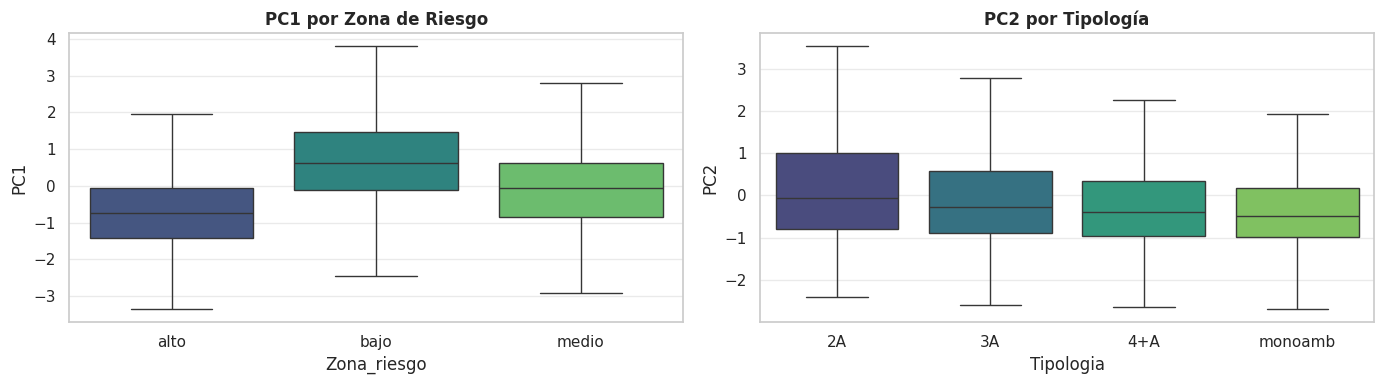

In [15]:
df_ana_full = df.loc[df_ana.index].copy()
df_ana_full = pd.concat([df_ana_full, df_scores], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, group_col, score_col, title in zip(
    axes,
    ['Zona_riesgo', 'Tipologia'],
    [SCORE_NAMES[0], SCORE_NAMES[1] if len(SCORE_NAMES) > 1 else SCORE_NAMES[0]],
    [f'{SCORE_NAMES[0]} por Zona de Riesgo',
     f'{SCORE_NAMES[1] if len(SCORE_NAMES) > 1 else SCORE_NAMES[0]} por Tipología']):
    if group_col not in df_ana_full.columns: continue
    order = sorted(df_ana_full[group_col].dropna().unique())
    sns.boxplot(data=df_ana_full.dropna(subset=[group_col, score_col]),
                x=group_col, y=score_col, order=order, palette='viridis', ax=ax,
                showfliers=False)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(group_col)
    ax.set_ylabel(score_col)
    ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [16]:
# ── Exportar para notebook 06 ────────────────────────────────────────────────
EXPORT_COLS = ['Precio_m2_USD','Rentabilidad_bruta_anual','Rentabilidad_neta_anual',
               'Payback_anios','Yield_gap_vs_bonos','Tipologia','Zona_riesgo','Comuna',
               'Barrio','confianza_renta','Indice_amenities','Sup_Cubierta_m2',
               'Distancia_subte_km','Distancia_parque_km','Tasa_delitos_comuna',
               'Liquidez_oferta_comuna','Volatilidad_Precio_m2_comuna','A_estrenar']

export_exist = [c for c in EXPORT_COLS if c in df_ana_full.columns]
df_export = pd.concat([df_ana_full[export_exist], df_scores], axis=1)
df_export.to_csv('dataset_ventas_pca_scores.csv', index=False)

print(f"✓ Exportado: dataset_ventas_pca_scores.csv")
print(f"  Shape: {df_export.shape}")
print(f"  Componentes: {SCORE_NAMES}")
print(f"  Columnas de contexto: {len(export_exist)}")

✓ Exportado: dataset_ventas_pca_scores.csv
  Shape: (3140, 22)
  Componentes: ['PC1', 'PC2', 'PC3', 'PC4']
  Columnas de contexto: 18


## 10. Síntesis

**Pipeline analítico documentado:**

1. **FA descartado** — KMO global = 0.42 (umbral mínimo: 0.50). Las variables no tienen
suficiente varianza compartida para sostener un modelo factorial. Este resultado *es en sí mismo
un hallazgo*: el mercado inmobiliario de CABA opera en dimensiones mayormente independientes,
sin constructos latentes claros.

2. **PCA aplicado como reductor agnóstico — N=4 componentes, 63.1% de varianza explicada.**
Se evaluó la reducción a N=3 (52% de varianza), descartada porque PC4 captura superficie de
forma casi exclusiva (loading 0.907) y sin ese eje el clustering no puede separar tipologías por
tamaño. El costo de 11 puntos porcentuales adicionales de varianza es aceptable dado el valor
interpretativo y operacional del componente.

3. **VIF de las variables originales bajo (máx ~2)** — confirma que la reducción con PCA no
resuelve un problema de multicolinealidad (no lo había). El PCA cumple aquí un rol *geométrico*
para el clustering, no de saneamiento estadístico.

4. **Estructura de los 4 ejes identificados:**
   - PC1 (21%): Valor de mercado — tensión precio/amenities vs rentabilidad
   - PC2 (17.8%): Accesibilidad urbana — distancias a infraestructura y liquidez
   - PC3 (13.5%): Riesgo contextual — volatilidad y conflictividad zonal
   - PC4 (11.6%): Tamaño — superficie como dimensión independiente

**Implicación para el fondo de inversión:** la decisión de inversión óptima requiere evaluar
simultáneamente cuatro ejes independientes. No existe un único score que capture la oportunidad:
una propiedad puede ser rentable (PC1 bajo), periférica (PC2 alto), segura (PC3 bajo) y chica
(PC4 bajo) al mismo tiempo — y ese perfil puede ser exactamente lo que busca el fondo según su
estrategia. El clustering del notebook 06 operará sobre estos 4 ejes para identificar grupos
naturales de propiedades con perfiles similares.

**Limitación reconocida:** el 63.1% de varianza explicada implica que aproximadamente un tercio
de la información del dataset no está representada en el espacio reducido. Esto no invalida el
clustering, pero los segmentos del notebook 06 deben leerse en conjunto con las medianas por
variable en escala original, no solo contra los scores de componentes.